# Notebook 04: Inflation Targeting Event Study (Exploratory)

- The question: does adopting inflation targeting change how much M2 growth passes through to inflation, especially short-run?
- Two angles: (1) event-study timing chart around adoption,
- (2) slope probe, does the M2 -> inflation coefficient shrink after adoption?
- Both are exploratory. 
- Also, Inflation targeting adoption is endogenous: countries choose IT when inflation is already falling.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from linearmodels.panel import PanelOLS


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "02_data/analysis_ready/macro_growth_merged.csv").exists():
            return candidate
    raise FileNotFoundError("Could not find project root with analysis-ready data.")


ROOT = find_project_root(Path.cwd().resolve())
PANEL_PATH = ROOT / "02_data/analysis_ready/macro_growth_merged.csv"
IT_DATES_PATH = ROOT / "02_data/supporting/it_adoption_dates.csv"
OUT_DIR = ROOT / "04_current_results/tables/inflation_targeting"
OUT_DIR.mkdir(parents=True, exist_ok=True)

panel = pd.read_csv(PANEL_PATH).rename(columns={"Country Name": "country"})
it = pd.read_csv(IT_DATES_PATH)

df = panel.merge(it, on="country", how="left")
df["it_treated"] = df["it_adoption_year_roger2010"].notna().astype(int)
df["post_it"] = (df["year"] >= df["it_adoption_year_roger2010"]).fillna(False).astype(int)
df["event_time"] = df["year"] - df["it_adoption_year_roger2010"]

# clean sample flag used in slope sensitivity (drop countries with any inflation >= 40%)
max_inf = df.groupby("country")["inflation"].max()
clean_countries = set(max_inf[max_inf < 0.40].index)
df["is_clean_country"] = df["country"].isin(clean_countries).astype(int)

# sample diagnostics
sample_summary = pd.DataFrame([
    {
        "countries_total": int(df["country"].nunique()),
        "countries_treated": int(df.loc[df["it_treated"] == 1, "country"].nunique()),
        "countries_never": int(df.loc[df["it_treated"] == 0, "country"].nunique()),
        "countries_clean": int(len(clean_countries)),
        "treated_in_clean": int(df.loc[(df["it_treated"] == 1) & (df["is_clean_country"] == 1), "country"].nunique()),
    }
])
sample_summary.to_csv(OUT_DIR / "04_sample_summary.csv", index=False)

# date coding check (Roger vs Hammond)
date_check = it[["country", "it_adoption_year_roger2010", "it_adoption_year_hammond2012"]].copy()
date_check["year_diff"] = date_check["it_adoption_year_roger2010"] - date_check["it_adoption_year_hammond2012"]
date_check_summary = pd.DataFrame([
    {
        "coded_countries": int(len(date_check)),
        "nonzero_diff_countries": int((date_check["year_diff"].abs() > 0).sum()),
        "max_abs_diff": float(date_check["year_diff"].abs().max()),
    }
])
date_check_summary.to_csv(OUT_DIR / "04_date_code_check.csv", index=False)

sample_summary


,countries_total,countries_treated,countries_never,countries_clean,treated_in_clean
0,160,27,133,123,19


In [2]:
# TWFE event-study on inflation levels (exploratory, strict event window)
# Keep never-treated rows as controls; for treated rows keep only exact t in [-5, 5].
event = df.copy()
event = event[(event["it_treated"] == 0) | (event["event_time"].between(-5, 5))].copy()
event["event_bin"] = event["event_time"]  # exact event time; no tail pooling

# support diagnostics: number of rows and countries by event time among treated
support_df = event[(event["it_treated"] == 1) & event["event_bin"].notna()].copy()
event_support = (
    support_df.groupby("event_bin")
    .agg(rows=("country", "size"), countries=("country", "nunique"))
    .reindex(range(-5, 6), fill_value=0)
    .reset_index()
    .rename(columns={"event_bin": "event_time"})
)
event_support.to_csv(OUT_DIR / "04_event_time_support.csv", index=False)

for k in range(-5, 6):
    if k == -1:
        continue
    event[f"evt_{k}"] = ((event["event_bin"] == k) & (event["it_treated"] == 1)).astype(int)

rhs_terms = " + ".join([f"`evt_{k}`" for k in range(-5, 6) if k != -1])
fit = event[["country", "year", "inflation", *[f"evt_{k}" for k in range(-5, 6) if k != -1]]].dropna()
fit = fit.set_index(["country", "year"])

es_res = PanelOLS.from_formula(
    f"inflation ~ 1 + {rhs_terms} + EntityEffects + TimeEffects",
    data=fit,
).fit(cov_type="clustered", cluster_entity=True)

es_table = pd.DataFrame({
    "term": es_res.params.index,
    "coef": es_res.params.values,
    "p_value": es_res.pvalues.values,
})
es_table.to_csv(OUT_DIR / "04_event_study_levels.csv", index=False)

# show both support and coefficients in notebook
print("Event-time support (treated):")
print(event_support.to_string(index=False))
es_table.head(12)


Event-time support (treated):
 event_time  rows  countries
         -5    19         19
         -4    20         20
         -3    20         20
         -2    22         22
         -1    24         24
          0    26         26
          1    27         27
          2    27         27
          3    27         27
          4    27         27
          5    27         27


,term,coef,p_value
0,Intercept,0.085064,0.000000
1,evt_-5,0.122244,0.412532
2,evt_-4,0.013413,0.705005
3,evt_-3,0.002460,0.873900
4,evt_-2,-0.000376,0.968399
5,evt_0,0.003100,0.746539
6,evt_1,-0.018340,0.181190
7,evt_2,-0.015860,0.352429
8,evt_3,-0.016049,0.289251
9,evt_4,-0.002510,0.868956


In [3]:
# Slope-focused probe: exploratory triple interaction (associational)
# Full-rank structure: it_m2 and post_treated_m2 (without redundant post_it_m2).

def run_slope_probe(input_df: pd.DataFrame):
    s = input_df[["country", "year", "inflation", "m2_growth", "it_treated", "post_it"]].dropna().copy()
    s["it_m2"] = s["it_treated"] * s["m2_growth"]
    s["post_treated_m2"] = s["post_it"] * s["it_treated"] * s["m2_growth"]
    s = s.set_index(["country", "year"])

    res = PanelOLS.from_formula(
        "inflation ~ 1 + m2_growth + it_m2 + post_treated_m2 + EntityEffects + TimeEffects",
        data=s,
    ).fit(cov_type="clustered", cluster_entity=True)

    out = {
        "coef_m2_growth": float(res.params["m2_growth"]),
        "p_m2_growth": float(res.pvalues["m2_growth"]),
        "coef_it_m2": float(res.params["it_m2"]),
        "p_it_m2": float(res.pvalues["it_m2"]),
        "coef_post_treated_m2": float(res.params["post_treated_m2"]),
        "p_post_treated_m2": float(res.pvalues["post_treated_m2"]),
        "implied_slope_it_pre": float(res.params["m2_growth"] + res.params["it_m2"]),
        "implied_slope_it_post": float(res.params["m2_growth"] + res.params["it_m2"] + res.params["post_treated_m2"]),
        "nobs": int(res.nobs),
        "countries": int(input_df["country"].nunique()),
        "treated_countries": int(input_df.loc[input_df["it_treated"] == 1, "country"].nunique()),
    }
    return res, out

# full sample
slope_res_full, full_row = run_slope_probe(df)
full_row["sample"] = "full"

# clean-country sensitivity sample
df_clean = df[df["is_clean_country"] == 1].copy()
slope_res_clean, clean_row = run_slope_probe(df_clean)
clean_row["sample"] = "clean"

slope_table = pd.DataFrame([full_row, clean_row])[[
    "sample", "countries", "treated_countries", "nobs",
    "coef_m2_growth", "p_m2_growth",
    "coef_it_m2", "p_it_m2",
    "coef_post_treated_m2", "p_post_treated_m2",
    "implied_slope_it_pre", "implied_slope_it_post",
]]

# Save both comparison and backward-compatible full-only file
slope_table.to_csv(OUT_DIR / "04_slope_probe_full_clean.csv", index=False)
slope_table[slope_table["sample"] == "full"].drop(columns=["sample"]).to_csv(OUT_DIR / "04_slope_probe.csv", index=False)

# default result object for plotting cell below
slope_res = slope_res_full

print("Exploratory only: post_treated_m2 is an associational slope difference, not a causal IT effect.")
slope_table


Exploratory only: post_treated_m2 is an associational slope difference, not a causal IT effect.


,sample,countries,treated_countries,nobs,coef_m2_growth,p_m2_growth,coef_it_m2,p_it_m2,coef_post_treated_m2,p_post_treated_m2,implied_slope_it_pre,implied_slope_it_post
0,full,160,27,4749,0.861501,0.000000e+00,-0.011113,0.914490,-0.460524,0.000001,0.850388,0.389863
1,clean,123,19,3638,0.092941,9.412915e-12,0.186440,0.004026,-0.241098,0.000392,0.279382,0.038283


## Q1: Did inflation level change at adoption?

Average inflation at exact event times `t = -5, ..., +5` around IT adoption (strict window; no pooled tails),
with a 95% confidence band for treated countries.

How to read this chart:
1. **Pre-trend diagnostic** (`t=-5` to `t=-1`): inflation is already falling before adoption, indicating endogenous timing and limiting causal interpretation.
2. **Post-adoption pattern** (`t=0` to `t=+5`): inflation continues to decline toward the never-adopter baseline, which is consistent with multiple mechanisms (policy, mean reversion, broader disinflation).

This cell is descriptive and exploratory.

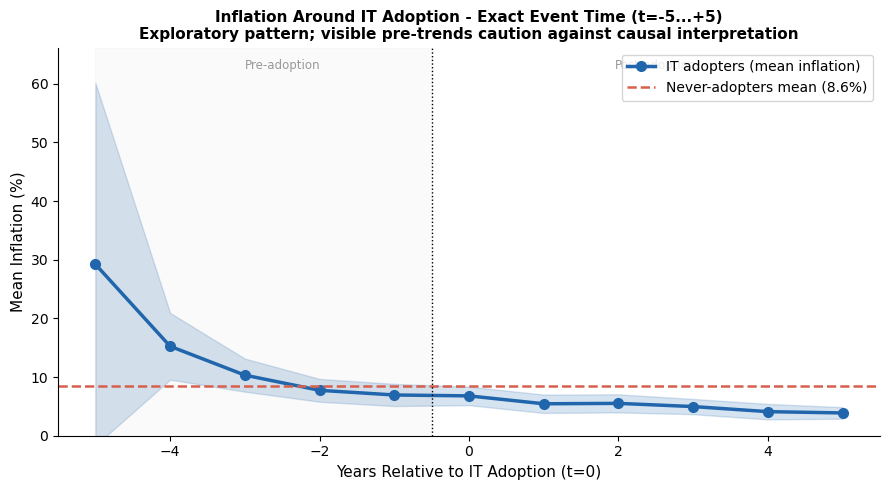

Saved -> it_event_time_inflation.png


In [4]:

# Event-time chart: average inflation level at exact t in [-5, 5]
import matplotlib.pyplot as plt
import numpy as np

event_adopters = df[(df["it_treated"] == 1) & df["event_time"].between(-5, 5)].dropna(subset=["inflation"]).copy()
event_adopters["event_bin"] = event_adopters["event_time"].astype(int)

et_stats = (
    event_adopters.groupby("event_bin")["inflation"]
    .agg(mean="mean", sem=lambda x: x.sem())
    .reindex(range(-5, 6))
)
et_stats["mean_pct"] = et_stats["mean"] * 100
et_stats["sem_pct"]  = et_stats["sem"]  * 100

never_mean_pct = df[df["it_treated"] == 0]["inflation"].mean() * 100
bins = list(range(-5, 6))
y    = et_stats["mean_pct"].tolist()
ye   = et_stats["sem_pct"].tolist()

ymax_val = max(
    max(v + 1.96 * e for v, e in zip(y, ye) if not np.isnan(v + e)),
    never_mean_pct,
) * 1.10

fig, ax = plt.subplots(figsize=(9, 5))

ax.fill_between(bins,
                [v - 1.96 * e for v, e in zip(y, ye)],
                [v + 1.96 * e for v, e in zip(y, ye)],
                alpha=0.18, color="#2166ac")
ax.plot(bins, y, color="#2166ac", lw=2.5, marker="o", ms=7,
        label="IT adopters (mean inflation)")
ax.axhline(never_mean_pct, color="#d6604d", lw=1.8, ls="--",
           label=f"Never-adopters mean ({never_mean_pct:.1f}%)")
ax.axvline(-0.5, color="black", lw=1.0, ls=":")
ax.axvspan(-5, -0.5, alpha=0.04, color="grey")

ax.text(-2.5, ymax_val * 0.97, "Pre-adoption", ha="center", fontsize=8.5,
        color="#999", va="top")
ax.text(2.5, ymax_val * 0.97, "Post-adoption", ha="center", fontsize=8.5,
        color="#999", va="top")

ax.set_ylim(0, ymax_val)
ax.set_xlabel("Years Relative to IT Adoption (t=0)", fontsize=11)
ax.set_ylabel("Mean Inflation (%)", fontsize=11)
ax.set_title(
    "Inflation Around IT Adoption - Exact Event Time (t=-5...+5)\n"
    "Exploratory pattern; visible pre-trends caution against causal interpretation",
    fontsize=11, fontweight="bold",
)
ax.legend(fontsize=10, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
fig.savefig(ROOT / "04_current_results/figures/it_event_time_inflation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> it_event_time_inflation.png")


## Q2: Did M2→inflation pass-through change after adoption?

Triple-interaction results are shown for full and clean samples in the table above.
The bar chart below visualizes the full-sample coefficients with 95% confidence intervals.
Interpretation remains exploratory: the post-adoption interaction term captures an associational
difference in slopes for IT adopters after adoption, under endogenous adoption timing.

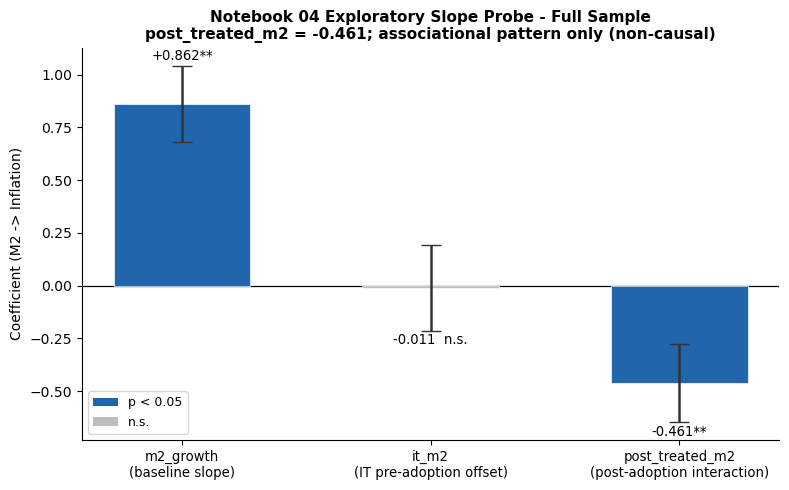

Saved -> it_slope_probe_coefficients.png


In [5]:
# Exploratory slope probe: full-sample coefficient bar chart (reads from slope_res above)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

terms   = ["m2_growth", "it_m2", "post_treated_m2"]
coefs   = [float(slope_res.params[t]) for t in terms]
ses     = [float(slope_res.std_errors[t]) for t in terms]
pvals   = [float(slope_res.pvalues[t]) for t in terms]
colors  = ["#2166ac" if p < 0.05 else "#bdbdbd" for p in pvals]
xlabels = [
    "m2_growth\n(baseline slope)",
    "it_m2\n(IT pre-adoption offset)",
    "post_treated_m2\n(post-adoption interaction)",
]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(3)
ax.bar(x, coefs, color=colors, width=0.55, zorder=3, edgecolor="white", lw=0.5)
ax.errorbar(x, coefs, yerr=[1.96 * s for s in ses],
            fmt="none", color="#333", capsize=7, lw=1.8, zorder=4)
ax.axhline(0, color="black", lw=0.9)
ax.set_xticks(x)
ax.set_xticklabels(xlabels, fontsize=9.5)
ax.set_ylabel("Coefficient (M2 -> Inflation)", fontsize=10)
ax.set_title(
    "Notebook 04 Exploratory Slope Probe - Full Sample\n"
    f"post_treated_m2 = {coefs[2]:+.3f}; associational pattern only (non-causal)",
    fontsize=11, fontweight="bold",
)
for i, (b, p, s) in enumerate(zip(coefs, pvals, ses)):
    star = "**" if p < 0.01 else ("*" if p < 0.05 else "")
    txt  = f"{b:+.3f}{star if star else '  n.s.'}"
    sign = 1 if b >= 0 else -1
    ax.text(i, b + sign * (1.96 * s + 0.012), txt,
            ha="center", va="bottom" if b >= 0 else "top", fontsize=9.5)

sig_p = mpatches.Patch(fc="#2166ac", label="p < 0.05")
ns_p  = mpatches.Patch(fc="#bdbdbd", label="n.s.")
ax.legend(handles=[sig_p, ns_p], fontsize=9, loc="lower left")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
(ROOT / "04_current_results/figures").mkdir(parents=True, exist_ok=True)
fig.savefig(ROOT / "04_current_results/figures/it_slope_probe_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> it_slope_probe_coefficients.png")
